In [2]:
%pip install pandas
%pip install matplotlib
import pandas as pd
# print("Pandas version:", pd.__version__)
import glob
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Find the data files in the data folder and sort by name
data = sorted(glob.glob('data/CRMLSSOLD*.csv'))
#print(data)

In [4]:
### Read and filter the CSV files according to the task doc requirements
## Explore distributions of ClosePrice (the target variable), LivingArea, Bedrooms, Bathrooms, LotSize.

# Bedrooms ==> BedroomsTotal
# Bathrooms ==> BathroomsTotalInteger
# LotSize ==> LotSizeAcres.

# csv = pd.read_csv(data[0], usecols=['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres', 'PropertyType', 'PropertySubType'])

## Restrict analysis to PropertyType = Residential and PropertySubType = SingleFamilyResidence (per task doc).
# csv = csv[(csv['PropertyType'] == 'Residential') & (csv['PropertySubType'] == 'SingleFamilyResidence')]
# check output
# print(csv)

all_csv = []

#apply filters to all files
for file in data:
    #print(f"Processing file: {file}")
    # Explore distributions
    csv = pd.read_csv(file, usecols=['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres', 'PropertyType', 'PropertySubType'])
    # restrict analysis per task doc
    csv = csv[(csv['PropertyType'] == 'Residential') & (csv['PropertySubType'] == 'SingleFamilyResidence')]

    all_csv.append(csv)

## Check total files read
print(f'Total files read: {len(all_csv)}')

Total files read: 6


In [5]:
### Combine all dataframes into one
df = pd.concat(all_csv, ignore_index=True)

#Reveals amount of rows and columns of the dataframe 
print(f'Size of combined DataFrame (rows, columns): {df.shape}')

Size of combined DataFrame (rows, columns): (61727, 7)


In [6]:
### Preview the first 5 rows of the combined DataFrame
df.head()

,ClosePrice,PropertyType,LivingArea,PropertySubType,LotSizeAcres,BathroomsTotalInteger,BedroomsTotal
0,1998000.0,Residential,2045.0,SingleFamilyResidence,0.2314,2.0,4.0
1,2214421.0,Residential,3050.0,SingleFamilyResidence,0.7976,4.0,4.0
2,1200000.0,Residential,1594.0,SingleFamilyResidence,0.1515,2.0,4.0
3,3100000.0,Residential,2700.0,SingleFamilyResidence,0.1897,3.0,5.0
4,2900000.0,Residential,2948.0,SingleFamilyResidence,0.2117,4.0,5.0


In [7]:
### Summary statistics
df.describe()

,ClosePrice,LivingArea,LotSizeAcres,BathroomsTotalInteger,BedroomsTotal
count,6.172700e+04,61697.000000,60644.000000,61726.000000,61727.000000
mean,1.340106e+06,2055.552918,10.828569,2.644801,3.498437
std,7.307629e+06,1037.243701,544.530184,1.135026,0.966684
min,1.750000e+00,0.000000,0.000000,0.000000,0.000000
25%,6.200000e+05,1386.000000,0.130000,2.000000,3.000000
50%,8.900000e+05,1826.000000,0.166800,2.000000,3.000000
75%,1.425000e+06,2455.000000,0.240000,3.000000,4.000000
max,7.960000e+08,23314.000000,60113.000000,22.000000,22.000000


In [8]:
### Check for missing values
df.isnull().sum()

ClosePrice                  0
PropertyType                0
LivingArea                 30
PropertySubType             0
LotSizeAcres             1083
BathroomsTotalInteger       1
BedroomsTotal               0
dtype: int64

count    6.172700e+04
mean     1.340106e+06
std      7.307629e+06
min      1.750000e+00
90%      2.300000e+06
95%      3.200000e+06
99%      6.500000e+06
max      7.960000e+08
Name: ClosePrice, dtype: float64


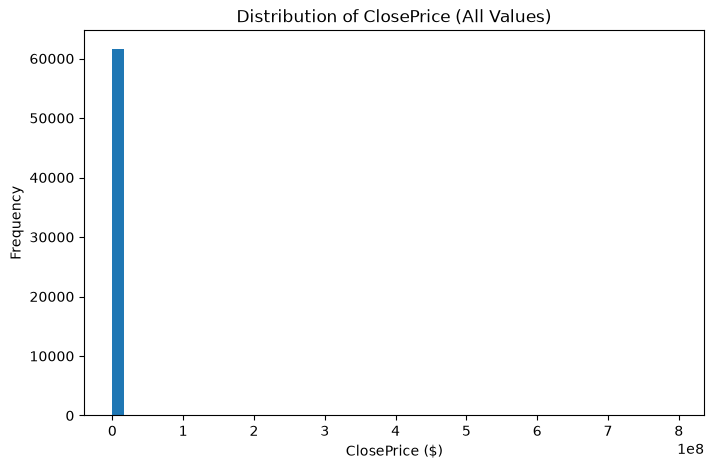

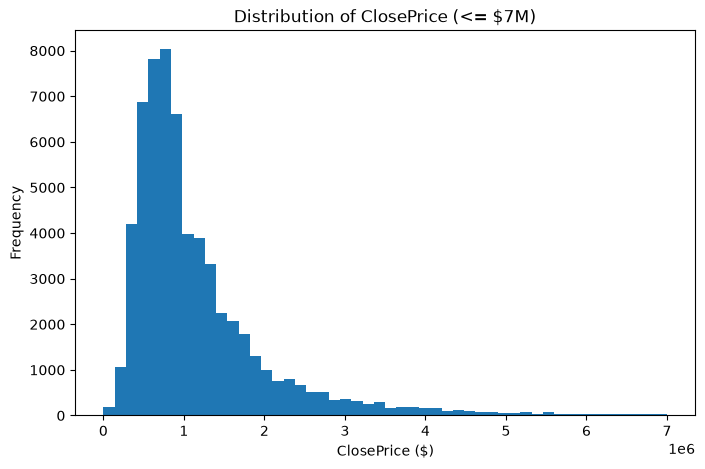

In [15]:
### Explore Distributions
## ClosePrice
# Defn: The amount of money paid by the purchaser to the seller for the property under the agreement

# Checking for outliers and percentiles in ClosePrice values
# print(df["ClosePrice"].max()) #796,000,000
# print(df["ClosePrice"].min()) #1.75
print(df["ClosePrice"].describe(percentiles=[0.90, 0.95, 0.99]))

# Full Distribution of ClosePrice values
plt.figure(figsize=(8, 5))
plt.hist(df["ClosePrice"], bins=50)
plt.title("Distribution of ClosePrice (All Values)")
plt.xlabel("ClosePrice ($)")
plt.ylabel("Frequency")
plt.show()

# Zoomed in on ClosePrice values less than or equal to $7M for better visualization of the distribution
plt.figure(figsize=(8, 5))
plt.hist(df[df["ClosePrice"] <= 7_000_000]["ClosePrice"], bins=50)
plt.title("Distribution of ClosePrice (<= $7M)")
plt.xlabel("ClosePrice ($)")
plt.ylabel("Frequency")
plt.show()

count    61697.000000
mean      2055.552918
std       1037.243701
min          0.000000
90%       3236.000000
95%       3838.000000
99%       5698.120000
max      23314.000000
Name: LivingArea, dtype: float64


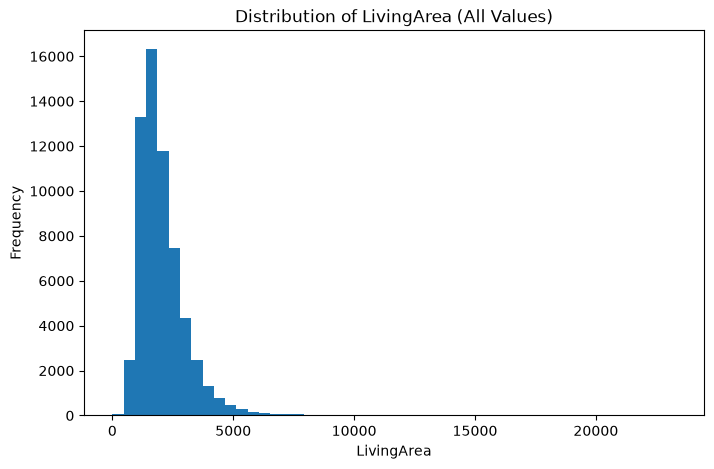

In [14]:
##Living Area
# Defn: The total livable area within the structure.

# Checking for outliers and percentiles in LivingArea values
print(df["LivingArea"].describe(percentiles=[0.90, 0.95, 0.99]))

# Full Distribution of LivingArea values
plt.figure(figsize=(8, 5))
plt.hist(df["LivingArea"], bins=50)
plt.title("Distribution of LivingArea (All Values)")
plt.xlabel("LivingArea")
plt.ylabel("Frequency")
plt.show()


count    61727.000000
mean         3.498437
std          0.966684
min          0.000000
90%          5.000000
95%          5.000000
99%          6.000000
max         22.000000
Name: BedroomsTotal, dtype: float64


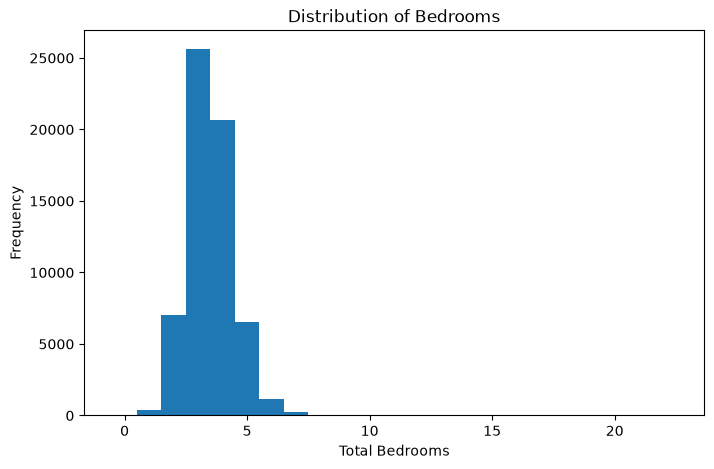

In [11]:
## Bedrooms = BedroomsTotal
# Defn: The total number of bedrooms in the property.

# Checking for outliers and percentiles in BedroomsTotal values
print(df["BedroomsTotal"].describe(percentiles=[0.90, 0.95, 0.99]))   

# Full Distribution of BedroomsTotal values
plt.figure(figsize=(8, 5))
plt.hist(df["BedroomsTotal"], bins=range(0, 24), align="left")
plt.title("Distribution of Bedrooms")
plt.xlabel("Total Bedrooms")
plt.ylabel("Frequency")
plt.show()


count    61726.000000
mean         2.644801
std          1.135026
min          0.000000
90%          4.000000
95%          5.000000
99%          6.000000
max         22.000000
Name: BathroomsTotalInteger, dtype: float64


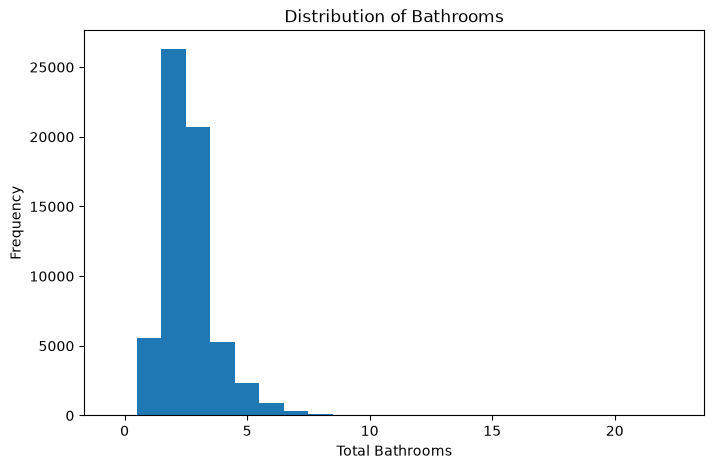

In [12]:
## Bathrooms = BathroomsTotalInteger
# Defn: The total number of bathrooms in the property.

# Checking for outliers and percentiles in BathroomsTotalInteger values
print(df["BathroomsTotalInteger"].describe(percentiles=[0.90, 0.95, 0.99]))  

# Full Distribution of BathroomsTotalInteger values
plt.figure(figsize=(8, 5))
plt.hist(df["BathroomsTotalInteger"], bins=range(0, 24), align="left")
plt.title("Distribution of Bathrooms")
plt.xlabel("Total Bathrooms")
plt.ylabel("Frequency")
plt.show()

count    60644.000000
mean        10.828569
std        544.530184
min          0.000000
90%          0.525180
95%          1.229085
99%          7.059700
max      60113.000000
Name: LotSizeAcres, dtype: float64


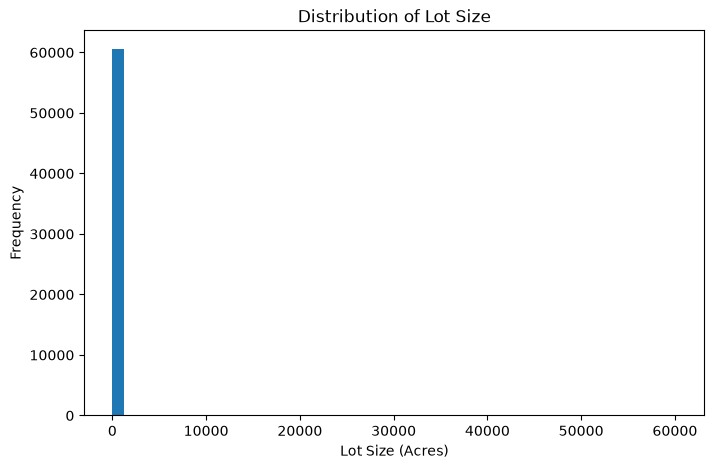

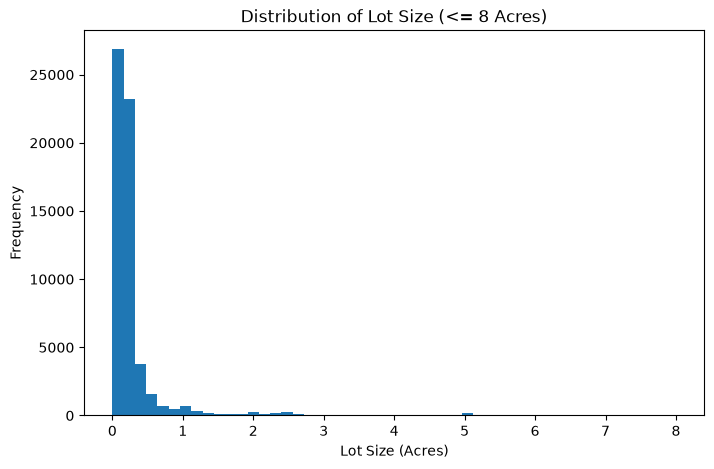

In [16]:
## LotSize = LotSizeAcres
# Defn: The total Acres of the lot.

# Checking for outliers and percentiles in LotSizeAcres values
print(df["LotSizeAcres"].describe(percentiles=[0.90, 0.95, 0.99]))   

# Full Distribution of LotSizeAcres values
plt.figure(figsize=(8, 5))
plt.hist(df["LotSizeAcres"], bins=50)
plt.title("Distribution of Lot Size")
plt.xlabel("Lot Size (Acres)")
plt.ylabel("Frequency")
plt.show()

# Zoomed in on LotSizeAcres values less than or equal to 8 Acres for better visualization of the distribution
plt.figure(figsize=(8, 5))
plt.hist(df[df["LotSizeAcres"] <= 8]["LotSizeAcres"], bins=50)
plt.title("Distribution of Lot Size (<= 8 Acres)")
plt.xlabel("Lot Size (Acres)")
plt.ylabel("Frequency")
plt.show()